In [ ]:
# Install Packages
# !pip install xarray netCDF4

In [1]:
!which python

/home/magesh/anaconda3/envs/mr-hyp/bin/python


In [19]:
import numpy as np
import xarray as xr
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.dates as md
import torch as th
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
from tqdm import tqdm

from sklearn.metrics import precision_recall_curve
import math
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import roc_auc_score as auc_score
from sklearn.metrics import average_precision_score as auprc
from sklearn.metrics import auc


from sklearn.preprocessing import StandardScaler, MinMaxScaler
ss = StandardScaler()
mm = MinMaxScaler()

In [24]:
import torch
import torch.nn as nn

class LSTMReg(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout=0.3, bidirectional=False):
        super(LSTMReg, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional

        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            dropout=dropout if num_layers > 1 else 0,
                            batch_first=True,
                            bidirectional=bidirectional)

        self.fc1 = nn.Linear(hidden_size * (2 if bidirectional else 1), hidden_size)
        self.relu = nn.ReLU()
        self.fc_out = nn.Linear(hidden_size, 1)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers * (2 if self.bidirectional else 1), x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers * (2 if self.bidirectional else 1), x.size(0), self.hidden_size).to(x.device)

        out, _ = self.lstm(x, (h0, c0))
        out = self.relu(self.fc1(out[:, -1, :]))
        return self.fc_out(out)


In [23]:
import torch
import torch.nn as nn

class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.3, bidirectional=True):
        super(LSTMClassifier, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0,
                            bidirectional=bidirectional)
        self.fc = nn.Linear(hidden_size * (2 if bidirectional else 1), output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers * (2 if self.bidirectional else 1), x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers * (2 if self.bidirectional else 1), x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        return self.fc(out[:, -1, :])


In [4]:
# !pip install xarray netCDF4

In [ ]:
#This code goes into the server

ds = xr.open_dataset('PEA_SOCalt_DCPtemp_hypxia_oxygen_depth_3D_2018_2020_exp14_2.nc', decode_times=False)
df = ds.to_dataframe()

#df = df[(df.index > pd.to_datetime('2013-01-01')) & (df.index < pd.to_datetime('2018-12-31'))]
#df = df[(df.index > pd.to_datetime('2018-01-01')) & (df.index < pd.to_datetime('2018-12-31'))]
#df_test = df[(df.index > pd.to_datetime('2019-01-01')) & (df.index < pd.to_datetime('2019-12-31'))]

df.reset_index(inplace=True)

df = df.dropna(axis=0)
df.head()

df = df[(df['SOCalt'] > 0.0) & (df['PEA'] > 0.0) & (df['DCPtemp'] > 0.0)]
df.shape
print("Shape of the dataframe: ", df.shape[0])

Shape of the dataframe:  2030709


In [6]:
df['ocean_time'] = df['ocean_time'].astype(int) - 719529

In [7]:
df['ocean_date_time'] = df['ocean_time'].apply(lambda x: md.num2date(x) if pd.notnull(x) else pd.NaT)
df['ocean_time'] = df['ocean_time']

In [8]:
df['ocean_date'] = pd.to_datetime(df['ocean_date_time']).dt.date

In [9]:
df = df.set_index('ocean_date')

df = df.sort_index()
df.head()

#df['day_of_year'] = df.ocean_date_time.dt.day_of_year

#df_scale_vector = df[['SOCalt', 'PEA', 'DCPtemp', 'depth', 'D Sin', 'D Cos', 'Y Sin', 'Y Cos', 'M Sin', 'M Cos', 'oxyg']]
#df_scale_vector_rbf = df[['SOCalt', 'PEA', 'DCPtemp', 'depth']]
df_scale_vector_rbf = df[['lat_rho', 'lon_rho', 'ocean_date_time', 'ocean_time', 'SOCalt', 'PEA', 'DCPtemp', 'depth', 'oxyg']]
#df_y = df[['oxyg']]

In [10]:
df_hyp = df_scale_vector_rbf.copy()

# 1 if Hypoxia and Non - Hypoxia 0
df_hyp['oxy_class'] = np.where(df_hyp['oxyg'] > 2.0, 0, 1)

In [11]:
df_1 = df_hyp.groupby('depth', group_keys=True).apply(lambda x: x)
# predictor = 'oxyg'
predictor = 'oxy_class'

/tmp/ipykernel_3513446/2674233037.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_1 = df_hyp.groupby('depth', group_keys=True).apply(lambda x: x)


In [12]:
def create_dataset(X, y, lookback):
    """
    Converts sequences into sliding window format for LSTM
    X: [n_samples, n_features]
    y: [n_samples, 1]
    Returns: tensors of shape (n_windows, lookback, n_features) and (n_windows, 1)
    """
    X1, y1 = [], []
    for i in range(len(X) - lookback):
        X1.append(X[i:i + lookback])
        y1.append(y[i + lookback])
    return th.tensor(np.array(X1), dtype=th.float32), th.tensor(np.array(y1), dtype=th.float32)

def prepare_dataset(df, predictor="oxy_class", lookback=7, test_year=2020, test_month=8, month_list=[5,6,7,8]):
    train_list_x, train_list_y = [], []
    test_list_x, test_list_y = [], []
    train_list_lat_lon, test_list_lat_lon = [], []

    for value in tqdm(df.depth.unique()):
        df_depth = df[(df['depth'] == value) & (df['ocean_date_time'].dt.month.isin(month_list))]
        df_test = df_depth[(df_depth['ocean_date_time'].dt.year == test_year) &
                           (df_depth['ocean_date_time'].dt.month == test_month)]
        df_train = df_depth[~df_depth.index.isin(df_test.index)]

        train_x_raw = df_train[['SOCalt', 'PEA', 'DCPtemp', 'depth']]
        test_x_raw = df_test[['SOCalt', 'PEA', 'DCPtemp', 'depth']]
        train_y_raw = df_train[[predictor]]
        test_y_raw = df_test[[predictor]]

        X_train_scaled = mm.fit_transform(train_x_raw)
        X_test_scaled = mm.transform(test_x_raw)

        if predictor != "oxy_class":
            y_train_scaled = mm.fit_transform(train_y_raw)
            y_test_scaled = mm.transform(test_y_raw)
        else:
            y_train_scaled = train_y_raw.values
            y_test_scaled = test_y_raw.values

        train_x, train_y = create_dataset(X_train_scaled, y_train_scaled, lookback)
        test_x, test_y = create_dataset(X_test_scaled, y_test_scaled, lookback)

        df_train_lat_lon = df_train[['lat_rho', 'lon_rho']].iloc[:-lookback]
        df_test_lat_lon = df_test[['lat_rho', 'lon_rho']].iloc[:-lookback]

        train_list_x.append(train_x)
        train_list_y.append(train_y)
        test_list_x.append(test_x)
        test_list_y.append(test_y)
        train_list_lat_lon.append(df_train_lat_lon)
        test_list_lat_lon.append(df_test_lat_lon)

    # Stack tensors
    X_train = th.vstack(train_list_x)
    y_train = th.vstack(train_list_y).squeeze(-1)
    X_test = th.vstack(test_list_x)
    y_test = th.vstack(test_list_y).squeeze(-1)

    # Lat/lon as DataFrames
    df_train_lat_lon = pd.concat(train_list_lat_lon, ignore_index=True)
    df_test_lat_lon = pd.concat(test_list_lat_lon, ignore_index=True)

    return X_train, y_train, X_test, y_test, df_train_lat_lon, df_test_lat_lon

In [13]:
def apply_smote(X_tensor, y_tensor):
    """
    Apply SMOTE to sequence data.
    X_tensor: (N, T, F)
    y_tensor: (N,)
    """
    X_flat = X_tensor.view(X_tensor.size(0), -1).cpu().numpy()
    y_np = y_tensor.cpu().numpy()

    smote = SMOTE()
    X_res, y_res = smote.fit_resample(X_flat, y_np)

    X_res_tensor = th.tensor(X_res, dtype=th.float32).view(-1, X_tensor.shape[1], X_tensor.shape[2])
    y_res_tensor = th.tensor(y_res, dtype=th.float32)

    return X_res_tensor, y_res_tensor

In [16]:
from imblearn.over_sampling import SMOTE

In [20]:
X_train, y_train, X_test, y_test, train_latlon, test_latlon = prepare_dataset(df_1, predictor="oxy_class", lookback=7)

# Apply SMOTE
X_train_smote, y_train_smote = apply_smote(X_train, y_train)

  0%|          | 0/2104 [00:00<?, ?it/s]

100%|██████████| 2104/2104 [01:47<00:00, 19.50it/s]


In [21]:
#num_classes = 1
# input_dim = 4
input_dim = 4
hidden_dim = 120

# change this to 1 or 2
output_dim = 2

# Layder dim =2
layer_dim = 2

In [29]:
device = th.device("cuda" if th.cuda.is_available() else "cpu")
print("Running on:", device)

Running on: cpu


In [30]:
model = LSTMClassifier(input_dim, hidden_dim, layer_dim, output_dim, dropout=0.3, bidirectional=True)
# model = LSTMClassfier(input_dim, hidden_dim, layer_dim, output_dim, X_train.shape[2])
# # model = LSTMReg(input_dim, hidden_dim, layer_dim, output_dim, X_train.shape[2])

# model = LSTMBinaryClassifier(input_dim, hidden_dim, layer_dim)
model = model.to(device)

learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# # loss_fn = nn.MSELoss()
loss_fn = nn.CrossEntropyLoss()

In [26]:
loader = data.DataLoader(data.TensorDataset(X_train_smote, y_train_smote), shuffle=False, batch_size=2048)

In [ ]:
# th.tensor(np.random.randint(2, size=(100,))).shape

In [ ]:
# # Driver for Regression

# n_epochs = 10
# for epoch in tqdm(range(n_epochs)):
#     model.train()
#     for X_batch, y_batch in (loader):
#         y_pred = model(X_batch)
#         y_batch = y_batch[:, -1, :]
#         loss = loss_fn(y_pred, y_batch)
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
#     # Validation
#     if epoch % 5 != 0:
#         continue
#     print("Epoch: %d, loss: %1.5f" % (epoch, loss.item()))
#     model.eval()
#     with th.no_grad():
#         y_pred = model(X_train)
#         y_t = y_train[:, -1, :]
#         train_rmse = np.sqrt(loss_fn(y_pred, y_t))
#         y_pred_test = model(X_test)
#         y_true = y_test[:, -1, :]
#         test_rmse = np.sqrt(loss_fn(y_pred_test, y_true))
#     print("Epoch %d: train RMSE %.4f, test RMSE %.4f" % (epoch, train_rmse, test_rmse))

In [31]:
# Driver for Classification
X_test = X_test.to(th.float32)
n_epochs = 10
for epoch in tqdm(range(n_epochs)):
    model.train()
    for X_batch, y_batch in (loader):
        # X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = model(X_batch)
        # y_batch = y_batch.float().view(-1)
        y_batch = y_batch.flatten().long()
        # print(y_pred.squeeze().shape, y_batch.shape)
        loss = loss_fn(y_pred.squeeze(), y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item():.4f}")

 10%|█         | 1/10 [01:24<12:43, 84.82s/it]

Epoch [1/10], Loss: 0.0000


 20%|██        | 2/10 [02:49<11:18, 84.79s/it]

Epoch [2/10], Loss: 0.0017


 30%|███       | 3/10 [04:13<09:51, 84.53s/it]

...

Epoch [8/10], Loss: 0.0085


 90%|█████████ | 9/10 [12:42<01:24, 84.92s/it]

Epoch [9/10], Loss: 0.0311


100%|██████████| 10/10 [14:07<00:00, 84.78s/it]

Epoch [10/10], Loss: 0.0242


In [ ]:
 # Validation
  # if epoch % 5 != 0:
  #     continue
  # print("Epoch: %d, loss: %1.5f" % (epoch, loss.item()))
  # model.eval()
  # with th.no_grad():
  #     y_pred_test = model(X_test.to(device))
  #     # predicted_labels = th.argmax(y_pred_test, dim=1)
  #     # y_probs = th.softmax(y_pred_test, dim=1)
  #     y_scores = y_probs[:, 1]
  #     print("Predicted Labels:", predicted_labels)

# Validation for Classification Model

In [32]:
model.eval()
with th.no_grad():
    y_pred_test = model(X_test)
    predicted_labels = th.argmax(y_pred_test, dim=1)
    y_true = y_test.numpy().flatten()
    y_scores = predicted_labels.numpy().flatten()

Evaluation Metrics
Log Loss: 3.5658
Brier Score Loss: 0.9063
AUC-ROC: 0.5421
AUC-PR (average_precision_score): 0.1345
AUC-PR (manual): 0.1345


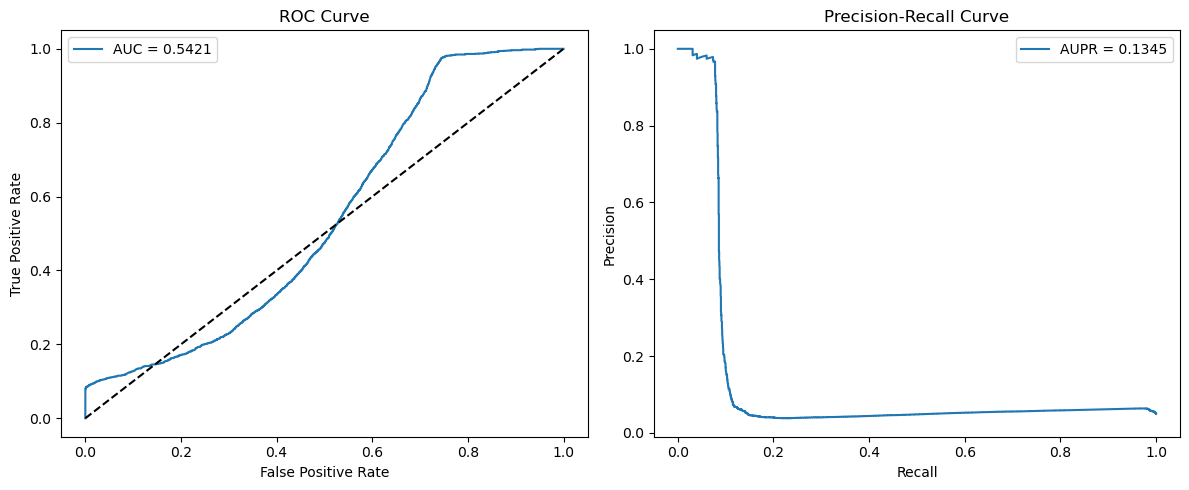

In [33]:
from sklearn.metrics import (
    log_loss,
    brier_score_loss,
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    auc
)

import matplotlib.pyplot as plt
import numpy as np

# Assuming y_pred_test contains raw logits
y_prob = th.softmax(y_pred_test, dim=1)[:, 1].cpu().numpy()  # predicted probability for class 1
y_pred = predicted_labels.cpu().numpy()
y_true = y_test.cpu().numpy().flatten()  # ensure compatibility

# Metrics
print("Evaluation Metrics")
print(f"Log Loss: {log_loss(y_true, y_prob):.4f}")
print(f"Brier Score Loss: {brier_score_loss(y_true, y_prob):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_true, y_prob):.4f}")
print(f"AUC-PR (average_precision_score): {average_precision_score(y_true, y_prob):.4f}")

# Precision-Recall AUC manually (for plotting)
precision, recall, _ = precision_recall_curve(y_true, y_prob)
aupr = auc(recall, precision)
print(f"AUC-PR (manual): {aupr:.4f}")

# McNemar's Test
cm = confusion_matrix(y_true, y_pred)
# if cm.shape == (2, 2):
#     result = mcnemar(cm, exact=False, correction=True)
#     print(f"McNemar’s Test p-value: {result.pvalue:.4f}")
# else:
#     print("McNemar's Test requires binary classification with a 2x2 confusion matrix.")

# Plot ROC and Precision-Recall Curves
fpr, tpr, _ = roc_curve(y_true, y_prob)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_true, y_prob):.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(recall, precision, label=f'AUPR = {aupr:.4f}')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.tight_layout()
plt.show()

In [34]:
from sklearn.metrics import confusion_matrix
from scipy.stats import chi2

# Confusion Matrix: rows = true, cols = predicted
cm = confusion_matrix(y_true, y_pred)

# McNemar's test uses only the off-diagonal values
# cm = [[TN, FP],
#        [FN, TP]]
if cm.shape != (2, 2):
    print("Error: McNemar's test requires a binary confusion matrix.")
else:
    b = cm[0, 1]  # false positives
    c = cm[1, 0]  # false negatives

    if b + c == 0:
        print("Perfect classifier or no disagreement — McNemar test is not applicable.")
    else:
        statistic = (abs(b - c) - 1)**2 / (b + c)  # with continuity correction
        p_value = 1 - chi2.cdf(statistic, df=1)

        print(f"McNemar's Test Statistic: {statistic:.4f}")
        print(f"McNemar's p-value: {p_value:.4f}")
        if p_value < 0.05:
            print("Result is statistically significant — classifier may be biased.")
        else:
            print("Result is NOT statistically significant — errors are likely random.")


McNemar's Test Statistic: 35987.0000
McNemar's p-value: 0.0000
Result is statistically significant — classifier may be biased.


In [35]:
cm

array([[    0, 35989],
       [    0,  1875]])

# Validation for Regression

In [ ]:
X_test_data = X_test.clone().detach()
y_test_data = y_test.clone().detach()
train_size = X_train.shape[0]
model.eval()
lookback = 7
with th.no_grad():
    train_true = y_train[:, -1, :].numpy()
    train_ = train_true.shape[0]
    # shift train predictions for plotting
    train_plot = np.ones_like(train_true) * np.nan
    y_pred = model(X_train)
    y_pred = y_pred.detach().numpy()
    y_pred = mm.inverse_transform(y_pred)
    train_true = mm.inverse_transform(train_true)
    print("Train RMSE: ", math.sqrt(mse(train_true, y_pred)))
    train_plot[:train_] = y_pred

Train RMSE:  1.0966168569907984


In [ ]:
with th.no_grad():
    # shift test predictions for plotting
    test_true = y_test[:, -1, :].numpy()
    test_ = test_true.shape[0]
    test_plot = np.ones_like(test_true) * np.nan
    y_pred_test = model(X_test)
    y_pred_test = y_pred_test.detach().numpy()
    y_pred_test = mm.inverse_transform(y_pred_test)
    test_true = mm.inverse_transform(test_true)
    print("Test RMSE: ", math.sqrt(mse(test_true, y_pred_test)))
    test_plot[:test_] = y_pred_test

Test RMSE:  1.8853202991902835


In [ ]:
class_train_true = np.where(train_true > 2.0, 1, 0)
class_train_pred = np.where(y_pred > 2.0, 1, 0)

class_test_true = np.where(test_true > 2.0, 1, 0)
class_test_pred = np.where(y_pred_test > 2.0, 1, 0)

In [ ]:
df_stacked_train_lat_lon['true_oxyg'] = class_train_true
df_stacked_train_lat_lon['pred_oxyg'] = class_train_pred
df_stacked_test_lat_lon['true_oxyg'] = class_test_true
df_stacked_test_lat_lon['pred_oxyg'] = class_test_pred

In [ ]:
df_stacked_train_lat_lon.shape, df_stacked_test_lat_lon.shape

((1950820, 4), (50433, 4))

In [ ]:
# df_stacked_test_lat_lon[20:],
test_true[20:], y_pred_test[20:], class_test_true[20:], class_test_pred[20:]

(array([[1.7509398],
        [1.6263772],
        [1.6237643],
        ...,
        [5.1421866],
        [4.7684636],
        [4.512082 ]], dtype=float32),
 array([[4.2249794],
        [4.1945558],
        [4.348583 ],
        ...,
        [4.040955 ],
        [3.9947488],
        [4.022419 ]], dtype=float32),
 array([[0],
        [0],
        [0],
        ...,
        [1],
        [1],
        [1]]),
 array([[1],
        [1],
        [1],
        ...,
        [1],
        [1],
        [1]]))

In [ ]:
import pickle
pd.to_pickle(df_stacked_train_lat_lon, 'df_stacked_train_lat_lon.pkl')
pd.to_pickle(df_stacked_test_lat_lon, 'df_stacked_test_lat_lon.pkl')

In [ ]:
y_pred, train_true

(array([[5.7392716],
        [5.9144726],
        [5.5833726],
        ...,
        [4.2565894],
        [4.336878 ],
        [4.4397626]], dtype=float32),
 array([[5.394328 ],
        [5.176567 ],
        [4.8895793],
        ...,
        [4.506302 ],
        [4.531836 ],
        [4.3690405]], dtype=float32))

In [ ]:
y_pred_test, test_true, class_test_pred, class_test_true

(array([[4.5982523],
        [4.5938787],
        [4.512078 ],
        ...,
        [3.981789 ],
        [4.0360594],
        [4.0285554]], dtype=float32),
 array([[1.6237714],
        [1.6237779],
        [1.6237885],
        ...,
        [5.1421866],
        [4.7684636],
        [4.512082 ]], dtype=float32),
 array([[1],
        [1],
        [1],
        ...,
        [1],
        [1],
        [1]]),
 array([[0],
        [0],
        [0],
        ...,
        [1],
        [1],
        [1]]))

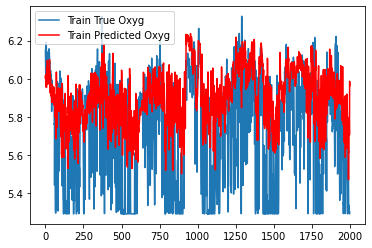

In [ ]:
plt.plot(train_true[:2000], label= "Train True Oxyg")
plt.plot(y_pred[:2000], c='r', label="Train Predicted Oxyg")
plt.legend()
plt.show()

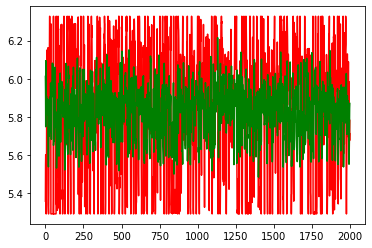

In [ ]:
plt.plot(test_true[:2000], c='r', label="Test True Oxyg")
plt.plot(y_pred_test[:2000], c='g', label="Test Predicted Oxyg")
plt.show()

In [ ]:
class_train_true = np.where(train_true > 2.0, 1, 0)
class_train_pred = np.where(y_pred > 2.0, 1, 0)

class_test_true = np.where(test_true > 2.0, 1, 0)
class_test_pred = np.where(y_pred_test > 2.0, 1, 0)

train_auprc = auprc(class_train_true, class_train_pred)
#train_auroc = auc_score(class_train_true, class_train_pred)

test_auprc = auprc(class_train_true, class_train_pred)
#test_auroc = auc_score(class_train_true, class_train_pred)

In [ ]:
class_test_true, class_test_pred

(array([[0],
        [0],
        [0],
        ...,
        [1],
        [1],
        [1]]),
 array([[1],
        [1],
        [1],
        ...,
        [1],
        [1],
        [1]]))

# Statistical Tests for regression

In [41]:
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import spearmanr

In [42]:
def pearson_corr(test_pred, test_true):
    return np.corrcoef(test_pred.flatten(), test_true)

In [48]:
def plot_residual(test_true, test_pred):
    residuals = [test_true[i] - test_pred[i] for i in range(len(test_true))]
    plt.scatter(test_pred, residuals)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    plt.savefig('residual_plot.png')
    plt.show()

In [51]:
def plot_matrics(y_true, y_pred):

    # Compute Pearson correlation
    pearson_corr, _ = stats.pearsonr(y_true, y_pred)

    # Compute Spearman correlation
    spearman_corr, _ = stats.spearmanr(y_true, y_pred)

    rho, p_value = spearmanr(y_true, y_scores)
    print(f"Pearson Correlation: {pearson_corr:.4f}, Spearman Correlation: {rho:.4f}, P-value: {p_value:.4f}")

In [52]:
plot_matrics(y_true, y_scores)

Pearson Correlation: -0.0017, Spearman Correlation: -0.0017, P-value: 0.7468


Spearman Correlation: 0.4242


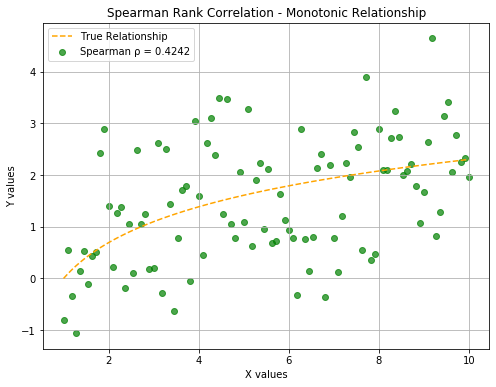

In [ ]:
from scipy.stats import spearmanr

# Generate example data (monotonic relationship)
x = np.linspace(1, 10, 100)
y = np.log(x) + np.random.randn(100)  # Monotonic but non-linear relationship

# Calculate Spearman correlation
spearman_corr, _ = spearmanr(x, y)
print(f"Spearman Correlation: {spearman_corr:.4f}")

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(x, y, label=f"Spearman ρ = {spearman_corr:.4f}", color="green", alpha=0.7)
plt.plot(x, np.log(x), color="orange", linestyle="--", label="True Relationship")
plt.xlabel("X values")
plt.ylabel("Y values")
plt.title("Spearman Rank Correlation - Monotonic Relationship")
plt.legend()
plt.grid(True)
plt.show()

Pearson Correlation: 0.9896


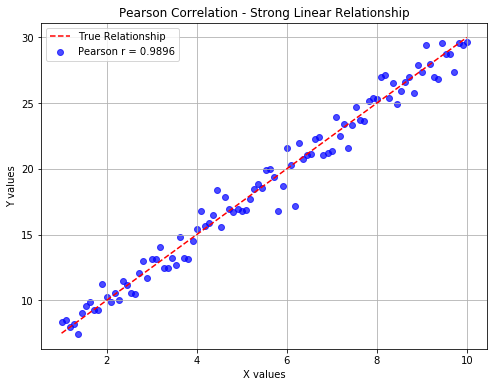

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Generate example data (strong linear relationship)
x = np.linspace(1, 10, 100)
y = 2.5 * x + 5 + np.random.randn(100)  # Linear relation with some noise

# Calculate Pearson correlation
pearson_corr, _ = pearsonr(x, y)
print(f"Pearson Correlation: {pearson_corr:.4f}")

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(x, y, label=f"Pearson r = {pearson_corr:.4f}", color="blue", alpha=0.7)
plt.plot(x, 2.5 * x + 5, color="red", linestyle="--", label="True Relationship")
plt.xlabel("X values")
plt.ylabel("Y values")
plt.title("Pearson Correlation - Strong Linear Relationship")
plt.legend()
plt.grid(True)
plt.show()

# Test Models for Binary Classifier and Regressor

In [38]:
# class LSTMClassifer(nn.Module):
#     def __init__(self, input_size, hidden_size, layer_d, output_d, seq_length):
#         super(LSTMClassifer, self).__init__()

#         self.hidden_dim = hidden_size #hidden layers
#         self.layer_dim = layer_d
#         self.input_size = input_size #input size
#         self.hidden_size = hidden_size #hidden state
#         self.seq_length = seq_length #sequence length
#         self.num_classes = output_d #number of classes

#         self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
#                           num_layers=output_d, batch_first=True) #lstm
#         #self.fc_1 =  nn.Linear(hidden_size, 128) #fully connected 1
#         self.fc = nn.Linear(hidden_size, output_d) #fully connected last layer

#         self.relu = nn.ReLU()

#     def forward(self,x):
#         h_0 = th.zeros(self.layer_dim, x.size(0), self.hidden_dim).requires_grad_()
#         c_0 = th.zeros(self.layer_dim, x.size(0), self.hidden_dim).requires_grad_()

#         # Propagate input through LSTM
#         output, (hn, cn) = self.lstm(x, (h_0, c_0)) #lstm with input, hidden, and internal state
#         out = self.fc(output[:, -1, :])
#         return out


# class LSTMBinaryClassifier(nn.Module):
#     def __init__(self, input_size, hidden_size, num_layers, dropout=0.2):
#         super(LSTMBinaryClassifier, self).__init__()

#         self.hidden_size = hidden_size
#         self.num_layers = num_layers

#         self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
#         self.fc = nn.Linear(hidden_size, 1)
#         self.sigmoid = nn.Sigmoid()

#     def forward(self, x):
#         h0 = th.zeros(self.num_layers, x.size(0), self.hidden_size) #.to(x.device)
#         c0 = th.zeros(self.num_layers, x.size(0), self.hidden_size) #.to(x.device)
#         out, _ = self.lstm(x, (h0, c0))
#         out = self.fc(out[:, -1, :])
#         out = self.sigmoid(out)
#         return out

# class LSTMReg(nn.Module):
#     def __init__(self, input_size, hidden_size, layer_d, output_d, seq_length, bidirectional=False):
#         super(LSTMReg, self).__init__()

#         self.hidden_dim = hidden_size #hidden layers
#         self.layer_dim = layer_d
#         # self.input_size = input_size #input size
#         self.hidden_size = hidden_size #hidden state
#         self.seq_length = seq_length #sequence length
#         # self.num_classes = output_d #number of classes
#         self.bidirectional = bidirectional  # If True, makes LSTM bidirectional

#         self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
#                           num_layers=layer_d, batch_first=True, bidirectional=bidirectional) #lstm
#         self.fc_1 =  nn.Linear(hidden_size, hidden_size) #fully connected 1
#         # self.fc = nn.Linear(hidden_size, output_d) #fully connected last layer
#         self.fc = nn.Linear(hidden_size, 1) #fully connected last layer

#         self.relu = nn.ReLU()

#     def forward(self,x):
#         num_directions = 2 if self.bidirectional else 1
#         h_0 = th.zeros(self.layer_dim * num_directions, x.size(0), self.hidden_dim).requires_grad_()
#         c_0 = th.zeros(self.layer_dim * num_directions, x.size(0), self.hidden_dim).requires_grad_()

#         # Propagate input through LSTM
#         output, (hn, cn) = self.lstm(x, (h_0, c_0)) #lstm with input, hidden, and internal state
#         hn = hn.view(-1, self.hidden_size) #reshaping the data for Dense layer next
#         out = self.relu(hn)
#         out = self.fc_1(out) #first Dense
#         out = self.relu(out) #relu
#         # out = self.fc(out) #Final Output
#         # out = self.fc(output[:, -1, :])
#         out = self.fc(out)
#         # print("LSTM output: ", out.shape)#         return out

#len((filtered_df['lat_rho'] + filtered_df['lon_rho']).unique())

# filtered_df = df_scale_vector_rbf.copy()

# filtered_df_2018 = filtered_df[(filtered_df['ocean_date_time'].dt.year == 2018) & (filtered_df['ocean_date_time'].dt.month.isin([5,6,7,8]))]
# filtered_df_2019 = filtered_df[(filtered_df['ocean_date_time'].dt.year == 2019) & (filtered_df['ocean_date_time'].dt.month.isin([5,6,7,8]))]
# filtered_df_2020 = filtered_df[(filtered_df['ocean_date_time'].dt.year == 2020) & (filtered_df['ocean_date_time'].dt.month.isin([5,6,7]))]
# filtered_df_2020_test = filtered_df[(filtered_df['ocean_date_time'].dt.year == 2020) & (filtered_df['ocean_date_time'].dt.month.isin([8]))]

# new_df = pd.concat([filtered_df_2018, filtered_df_2019, filtered_df_2020])

# train_df = new_df.copy()

# #train_size = int(len(filtered_df) * 0.80)
# #test_size = len(filtered_df) - train_size
# #train, test = filtered_df[:train_size], filtered_df[train_size:]
# train, test = train_df, filtered_df_2020_test

# train_feature_list = ['lat_rho', 'lon_rho', 'SOCalt', 'PEA', 'DCPtemp', 'depth']
# #train_feature_list = [predictor]
# #train_feature_list = ['Solar Rad']
# test_feature_list = ['oxyg']
# X_trans_train = ss.fit_transform(train[train_feature_list])
# X_trans_test = ss.transform(test[train_feature_list])
# y_trans_train = mm.fit_transform(train[test_feature_list])
# y_trans_test = mm.fit_transform(test[test_feature_list])

# lookback = 2130*30 # Set for a month
# X_train, y_train = create_dataset(X_trans_train, y_trans_train, lookback=lookback)
# X_test, y_test = create_dataset(X_trans_test, y_trans_test, lookback=lookback)
# print(X_train.shape, y_train.shape# print(X_test.shape, y_test.shape)